In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

DATA_DIR = "../data/processed/"
FIGURE_DIR = "../output/figures/"

master = pd.read_csv(
    DATA_DIR + "master_data.csv"
)

master.head()



,city_id,year,population,registered_population,age_0_14,age_15_64,age_65_plus,urbanization_rate,population_density,average_wage,...,primary_employment,secondary_employment,tertiary_employment,industry_employment_total,disposable_income,consumption_expenditures,urban_consumption_expenditures,rural_consumption_expenditures,urban_disposable_income,rural_disposable_income
0,city1,2000,NaN,NaN,49.0,178.0,36.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,city1,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10340.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,city1,2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13044.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,city1,2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16648.0,...,0.0,57.0,41.0,98.0,NaN,NaN,NaN,NaN,NaN,NaN
4,city1,2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19968.0,...,0.0,63.0,43.0,106.0,NaN,NaN,NaN,NaN,NaN,NaN


# 建立建模副本

In [178]:
model_data = master.copy()

model_data = (
    model_data
    .sort_values(["city_id", "year"])
    .reset_index(drop=True)
)

model_data.loc[
    model_data["population"] == 0,
    "population"
] = np.nan

# 把人口为0当作不可用值



# 构造上一年人口lag1，前两年人口lag2 

In [179]:
model_data["population_lag1"] = (
    model_data
    .groupby("city_id")["population"]
    .shift(1)
)

model_data["population_lag2"] = (
    model_data
    .groupby("city_id")["population"]
    .shift(2)
)

# 确保年份连续（连续才可预测）

In [180]:
model_data["year_lag1"] = (
    model_data
    .groupby("city_id")["year"]
    .shift(1)
)

model_data["year_lag2"] = (
    model_data
    .groupby("city_id")["year"]
    .shift(2)
)

model_data["gap_lag1"] = (
    model_data["year"]
    - model_data["year_lag1"]
)

model_data["gap_lag2"] = (
    model_data["year"]
    - model_data["year_lag2"]
)

# 构造人口变化量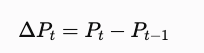

In [181]:
model_data["population_diff1"] = np.where(
    (
        (model_data["gap_lag1"] == 1)
        &
        (model_data["population_lag1"] > 0)
    ),

    model_data["population"]
    - model_data["population_lag1"],

    np.nan
)

# 构造人口增长率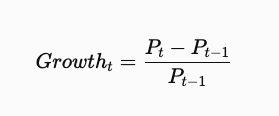

In [182]:
model_data["population_growth1"] = np.where(
    (
        (model_data["gap_lag1"] == 1)
        &
        (model_data["population_lag1"] > 0)
    ),

    (
        model_data["population"]
        - model_data["population_lag1"]
    )
    / model_data["population_lag1"],

    np.nan
)

# 构造两年平均变化量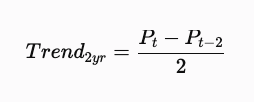

In [183]:
model_data["population_diff2_avg"] = np.where(
    (
        (model_data["gap_lag2"] == 2)
        &
        (model_data["population_lag2"] > 0)
    ),

    (
        model_data["population"]
        - model_data["population_lag2"]
    ) / 2,

    np.nan
)

# 构造预测目标

In [184]:
model_data["target_population_2y"] = (
    model_data
    .groupby("city_id")["population"]
    .shift(-2)
)

model_data["target_year"] = (
    model_data
    .groupby("city_id")["year"]
    .shift(-2)
)

model_data[
    [
        "city_id",
        "year",
        "population",
        "target_year",
        "target_population_2y"
    ]
].head(20)

,city_id,year,population,target_year,target_population_2y
0,city1,2000,NaN,2002.0,NaN
1,city1,2001,NaN,2003.0,NaN
2,city1,2002,NaN,2004.0,NaN
3,city1,2003,NaN,2005.0,NaN
4,city1,2004,NaN,2006.0,272.0
5,city1,2005,NaN,2007.0,277.0
6,city1,2006,272.0,2008.0,280.0
7,city1,2007,277.0,2009.0,282.0
8,city1,2008,280.0,2010.0,285.0
9,city1,2009,282.0,2011.0,289.0


# 排除年份断档

In [185]:
model_data["target_population_2y"] = np.where(
    model_data["target_year"] - model_data["year"] == 2,
    model_data["target_population_2y"],
    np.nan
)

# 查看特征（放ppt）

In [186]:
model_data[
    [
        "city_id",
        "year",
        "population",
        "population_lag1",
        "population_lag2",
        "population_diff1",
        "population_growth1",
        "population_diff2_avg",
        "target_year",
        "target_population_2y"
    ]
].head(30)

model_data.to_csv(
    DATA_DIR + "model_data.csv",
    index=False
)

# 建立历史验证集

In [187]:
valid_2021 = model_data[
    model_data["target_year"] == 2021
].copy()

valid_2021 = valid_2021.dropna(
    subset=[
        "population",
        "target_population_2y"
    ]
)
#仅有留下真实目标的
valid_2021 = valid_2021[
    (valid_2021["population"] > 0)
    &
    (valid_2021["target_population_2y"] > 0)
]
#过滤不合理0
valid_2021[
    [
        "city_id",
        "year",
        "population",
        "target_year",
        "target_population_2y"
    ]
].head()
#输出检查

,city_id,year,population,target_year,target_population_2y
19,city1,2019,303.0,2021.0,337.0
42,city10,2019,220.0,2021.0,251.0
65,city11,2019,473.0,2021.0,540.0
88,city12,2019,464.0,2021.0,452.0
111,city13,2019,493.0,2021.0,499.0


# 预测baseline1：人口保持不变（2019 人口直接作为 2021 预测值），并且计算mse
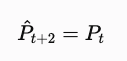

In [188]:
valid_2021["pred_baseline_last"] = (
    valid_2021["population"]
)

mse_last = mean_squared_error(
    valid_2021["target_population_2y"],
    valid_2021["pred_baseline_last"]
)

print("Baseline Last MSE:", mse_last)

Baseline Last MSE: 5133.05


# Baseline 2：最近趋势外推

In [189]:
valid_trend = valid_2021.dropna(
    subset=[
        "population_lag1",
        "population_diff1"
    ]
).copy()

valid_trend["pred_baseline_trend"] = (
    valid_trend["population"]
    +
    2 * valid_trend["population_diff1"]
)

mse_trend = mean_squared_error(
    valid_trend["target_population_2y"],
    valid_trend["pred_baseline_trend"]
)

print("Trend Baseline MSE:", mse_trend)

Trend Baseline MSE: 3457.55


# 计算rmse（与评分无关，放入ppt方便理解）

In [190]:
rmse_last = np.sqrt(mse_last)
rmse_trend = np.sqrt(mse_trend)

print("Last Baseline RMSE:", rmse_last)
print("Trend Baseline RMSE:", rmse_trend)

Last Baseline RMSE: 71.64530689445053
Trend Baseline RMSE: 58.80093536670994


# 模型结果比较表

In [191]:
baseline_result = pd.DataFrame({
    "model": [
        "Last Population",
        "Linear Trend"
    ],

    "MSE": [
        mse_last,
        mse_trend
    ],

    "RMSE": [
        rmse_last,
        rmse_trend
    ]
})

baseline_result

baseline_result.to_csv(
    DATA_DIR + "baseline_result.csv",
    index=False
)

# 预测表转图

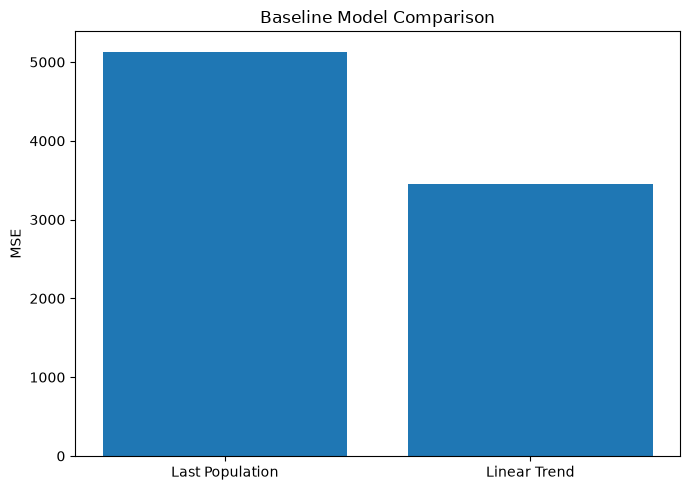

In [192]:
plt.figure(figsize=(7, 5))

plt.bar(
    baseline_result["model"],
    baseline_result["MSE"]
)

plt.ylabel("MSE")
plt.title("Baseline Model Comparison")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR + "09_baseline_mse.png",
    dpi=300
)

plt.show()

# 城市预测结果

In [193]:
baseline_detail = valid_trend[
    [
        "city_id",
        "year",
        "population",
        "target_population_2y",
        "pred_baseline_trend"
    ]
].copy()

baseline_detail["error"] = (
    baseline_detail["pred_baseline_trend"]
    -
    baseline_detail["target_population_2y"]
)

baseline_detail["abs_error"] = (
    baseline_detail["error"].abs()
)

baseline_detail.sort_values(
    "abs_error",
    ascending=False
).head(10)

,city_id,year,population,target_population_2y,pred_baseline_trend,error,abs_error
821,city5,2019,1072.0,1275.0,1080.0,-195.0,195.0
387,city24,2019,746.0,920.0,774.0,-146.0,146.0
318,city21,2019,981.0,1194.0,1049.0,-145.0,145.0
249,city19,2019,560.0,705.0,570.0,-135.0,135.0
272,city2,2019,657.0,746.0,661.0,-85.0,85.0
409,city25,2019,820.0,940.0,858.0,-82.0,82.0
341,city22,2019,844.0,932.0,864.0,-68.0,68.0
523,city3,2019,1666.0,1763.0,1824.0,61.0,61.0
226,city18,2019,470.0,525.0,470.0,-55.0,55.0
65,city11,2019,473.0,540.0,487.0,-53.0,53.0


# 检查test dataset

In [194]:
TEST_PATH = "../data/raw/test.xls"

test = pd.read_excel(TEST_PATH)

test.head()

,年份,常住人口,城镇化率,失业率,第一产业人数,第二产业人数,第三产业人数,0-14,15-65,65+,户籍人口,人均可支配收入,城镇居民消费支出
0,2014,414,47,2,90,48,72,45,303,49,522,13327,12849
1,2015,411,45,2,78,60,69,61,292,50,528,14892,14064
2,2016,407,45,2,78,60,72,67,281,51,543,16404,15294
3,2017,404,46,2,78,63,72,73,270,52,549,17985,16833
4,2018,400,48,2,78,63,72,79,259,53,549,19635,18474


In [195]:
print("Shape:", test.shape)
print()

print("Columns:")
print(test.columns.tolist())
print()

print(test.head(10))
print()

print(test.info())


Shape: (10, 13)

Columns:
['年份', '常住人口', '城镇化率', '失业率', '第一产业人数', '第二产业人数', '第三产业人数', '0-14', '15-65', '65+', '户籍人口', '人均可支配收入', '城镇居民消费支出']

     年份  常住人口  城镇化率  失业率  第一产业人数  第二产业人数  第三产业人数  0-14  15-65  65+  户籍人口  \
0  2014   414    47    2      90      48      72    45    303   49   522   
1  2015   411    45    2      78      60      69    61    292   50   528   
2  2016   407    45    2      78      60      72    67    281   51   543   
3  2017   404    46    2      78      63      72    73    270   52   549   
4  2018   400    48    2      78      63      72    79    259   53   549   
5  2019   396    49    2      78      27      57    85    248   54   546   
6  2020   392    52    2      75      30      60    91    241   56   543   
7  2021   387    52    2      42      36      87    97    228   57   543   
8  2022   388    53    2      29      40      98   103    217   58   540   
9  2023   384    54    2      31      44      96   105    220   59   545   

   人均可支配收入  城镇居民消费支出 

In [196]:
print("缺失值：")
print(test.isna().sum())

print()

print("重复记录：")
print(test.duplicated().sum())

缺失值：
年份          0
常住人口        0
城镇化率        0
失业率         0
第一产业人数      0
第二产业人数      0
第三产业人数      0
0-14        0
15-65       0
65+         0
户籍人口        0
人均可支配收入     0
城镇居民消费支出    0
dtype: int64

重复记录：
0


In [197]:
test.shape

(10, 13)

In [198]:
test.columns.tolist()

['年份',
 '常住人口',
 '城镇化率',
 '失业率',
 '第一产业人数',
 '第二产业人数',
 '第三产业人数',
 '0-14',
 '15-65',
 '65+',
 '户籍人口',
 '人均可支配收入',
 '城镇居民消费支出']

In [199]:
test.head()

,年份,常住人口,城镇化率,失业率,第一产业人数,第二产业人数,第三产业人数,0-14,15-65,65+,户籍人口,人均可支配收入,城镇居民消费支出
0,2014,414,47,2,90,48,72,45,303,49,522,13327,12849
1,2015,411,45,2,78,60,69,61,292,50,528,14892,14064
2,2016,407,45,2,78,60,72,67,281,51,543,16404,15294
3,2017,404,46,2,78,63,72,73,270,52,549,17985,16833
4,2018,400,48,2,78,63,72,79,259,53,549,19635,18474


In [200]:
print("年份：")
print(test["年份"].tolist())

print("\n最后10行：")
display(test.tail(10))

print("\n各字段缺失值：")
print(test.isna().sum())

print("\n数据类型：")
print(test.dtypes)

年份：
[2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]

最后10行：


,年份,常住人口,城镇化率,失业率,第一产业人数,第二产业人数,第三产业人数,0-14,15-65,65+,户籍人口,人均可支配收入,城镇居民消费支出
0,2014,414,47,2,90,48,72,45,303,49,522,13327,12849
1,2015,411,45,2,78,60,69,61,292,50,528,14892,14064
2,2016,407,45,2,78,60,72,67,281,51,543,16404,15294
3,2017,404,46,2,78,63,72,73,270,52,549,17985,16833
4,2018,400,48,2,78,63,72,79,259,53,549,19635,18474
5,2019,396,49,2,78,27,57,85,248,54,546,21216,18657
6,2020,392,52,2,75,30,60,91,241,56,543,22902,19446
7,2021,387,52,2,42,36,87,97,228,57,543,23871,19479
8,2022,388,53,2,29,40,98,103,217,58,540,26208,21414
9,2023,384,54,2,31,44,96,105,220,59,545,27633,22081



各字段缺失值：
年份          0
常住人口        0
城镇化率        0
失业率         0
第一产业人数      0
第二产业人数      0
第三产业人数      0
0-14        0
15-65       0
65+         0
户籍人口        0
人均可支配收入     0
城镇居民消费支出    0
dtype: int64

数据类型：
年份          int64
常住人口        int64
城镇化率        int64
失业率         int64
第一产业人数      int64
第二产业人数      int64
第三产业人数      int64
0-14        int64
15-65       int64
65+         int64
户籍人口        int64
人均可支配收入     int64
城镇居民消费支出    int64
dtype: object


In [201]:
display(
    test[
        test["年份"] >= 2020
    ]
)

,年份,常住人口,城镇化率,失业率,第一产业人数,第二产业人数,第三产业人数,0-14,15-65,65+,户籍人口,人均可支配收入,城镇居民消费支出
6,2020,392,52,2,75,30,60,91,241,56,543,22902,19446
7,2021,387,52,2,42,36,87,97,228,57,543,23871,19479
8,2022,388,53,2,29,40,98,103,217,58,540,26208,21414
9,2023,384,54,2,31,44,96,105,220,59,545,27633,22081


In [202]:
display(
    test[
        test["年份"] == 2023
    ].T
)

,9
年份,2023
常住人口,384
城镇化率,54
失业率,2
第一产业人数,31
第二产业人数,44
第三产业人数,96
0-14,105
15-65,220
65+,59
